<a href="https://colab.research.google.com/github/Rasmy-r7/Research/blob/main/RoBERTa_base%26CodeBERT_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#═══════════════════════════════════════════════════════════════
# STEP 1: Install required packages
# Run this first, then restart runtime
#═══════════════════════════════════════════════════════════════
import os
os.environ["WANDB_DISABLED"] = "true"

!pip uninstall transformers accelerate peft sentence-transformers -y -q
!pip install transformers==4.41.0 accelerate==0.27.2 -q
!pip install sentence-transformers -q

print("✅ Installation complete!")
print("   → Runtime → Restart Session → OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 15.2 MB/s eta 0:00:00
✅ Installation complete!
   → Runtime → Restart Session → OK


In [3]:
#═══════════════════════════════════════════════════════════════
# STEP 2: Import all libraries
# Run immediately after restarting runtime
#═══════════════════════════════════════════════════════════════
import os, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

os.environ["WANDB_DISABLED"] = "true"

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All libraries imported!")
print(f"   Device : {device}")
if not torch.cuda.is_available():
    print("   ⚠️  No GPU! → Runtime → Change Runtime Type → T4 GPU")

✅ All libraries imported!
   Device : cuda


In [4]:
#═══════════════════════════════════════════════════════════════
# STEP 3: Upload and load all 3 CSV files
# Required columns: text, priority, priority_id
#═══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your 3 CSV files:")
print("   1. train_combined.csv")
print("   2. val_combined.csv")
print("   3. test_combined.csv")

uploaded = files.upload()

train_df = pd.read_csv("train_combined.csv")
val_df   = pd.read_csv("val_combined.csv")
test_df  = pd.read_csv("test_combined.csv")

# ── Validate columns ─────────────────────────────────────────
for name, df in [("train", train_df),
                 ("val",   val_df),
                 ("test",  test_df)]:
    assert 'text'        in df.columns, f"❌ Missing 'text' in {name}"
    assert 'priority_id' in df.columns, f"❌ Missing 'priority_id' in {name}"
    assert 'priority'    in df.columns, f"❌ Missing 'priority' in {name}"

# ── Label config ─────────────────────────────────────────────
LABEL_MAP   = {'High': 0, 'Medium': 1, 'Low': 2}
INV_LABEL   = {0: 'High', 1: 'Medium', 2: 'Low'}
NUM_CLASSES = 3

for df in [train_df, val_df, test_df]:
    df['priority_id'] = df['priority_id'].astype(int)

print(f"\n✅ All files loaded!")
print(f"   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"\n   Label distribution (train):")
print(train_df['priority'].value_counts().to_string())

Upload your 3 CSV files:
   1. train_combined.csv
   2. val_combined.csv
   3. test_combined.csv


Saving test_combined.csv to test_combined.csv
Saving val_combined.csv to val_combined.csv
Saving train_combined.csv to train_combined.csv

✅ All files loaded!
   Train : 23,274 rows
   Val   : 2,909 rows
   Test  : 2,910 rows

   Label distribution (train):
priority
Medium    9430
High      8550
Low       5294


In [5]:
#═══════════════════════════════════════════════════════════════
# STEP 4: Load RoBERTa-base + CodeBERT
#
# RoBERTa-base : 12 layers, 768 dims
#                strong general-language understanding
#                replaces TinyBERT (4 layers, 312 dims)
#
# CodeBERT     : 12 layers, 768 dims
#                technical/code-aware language patterns
#
# Balanced "v5" unfreezing: last 2 layers + pooler of EACH model
# (between v1's frozen-everything and v3's heavy unfreezing)
#═══════════════════════════════════════════════════════════════
ROBERTA_NAME  = "roberta-base"
CODEBERT_NAME = "microsoft/codebert-base"

print("Loading RoBERTa-base...")
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta_model     = AutoModel.from_pretrained(ROBERTA_NAME).to(device)

print("Loading CodeBERT...")
codebert_tokenizer = AutoTokenizer.from_pretrained(CODEBERT_NAME)
codebert_model     = AutoModel.from_pretrained(CODEBERT_NAME).to(device)

# ── Freeze all layers first ──────────────────────────────────
for m in [roberta_model, codebert_model]:
    for param in m.parameters():
        param.requires_grad = False

# ── Unfreeze last 2 layers of RoBERTa + pooler ──────────────
# RoBERTa-base has 12 layers (0..11)
for name, param in roberta_model.named_parameters():
    if any(f"layer.{i}" in name for i in [10, 11]):
        param.requires_grad = True
    if 'pooler' in name:
        param.requires_grad = True

# ── Unfreeze last 2 layers of CodeBERT + pooler ─────────────
for name, param in codebert_model.named_parameters():
    if any(f"layer.{i}" in name for i in [10, 11]):
        param.requires_grad = True
    if 'pooler' in name:
        param.requires_grad = True

# ── Embedding dimensions ─────────────────────────────────────
ROBERTA_DIM  = 768
CODEBERT_DIM = 768
FUSED_DIM    = ROBERTA_DIM + CODEBERT_DIM   # 1536

rob_trainable  = sum(p.numel() for p in roberta_model.parameters()
                     if p.requires_grad)
code_trainable = sum(p.numel() for p in codebert_model.parameters()
                     if p.requires_grad)

print(f"\n✅ Both models loaded!")
print(f"   RoBERTa  trainable : {rob_trainable:,} params (layers 10-11 + pooler)")
print(f"   CodeBERT trainable : {code_trainable:,} params (layers 10-11 + pooler)")
print(f"   Fused dim          : {FUSED_DIM}")

Loading RoBERTa-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]


✅ Both models loaded!
   RoBERTa  trainable : 14,766,336 params (layers 10-11 + pooler)
   CodeBERT trainable : 14,766,336 params (layers 10-11 + pooler)
   Fused dim          : 1536


In [6]:
#═══════════════════════════════════════════════════════════════
# STEP 5: FusionDataset
# Tokenizes each text TWICE:
#   → RoBERTa tokenizer
#   → CodeBERT tokenizer
#═══════════════════════════════════════════════════════════════
MAX_LENGTH = 128
BATCH_SIZE = 16

class FusionDataset(Dataset):
    def __init__(self, dataframe, rob_tokenizer,
                 code_tokenizer, max_length=MAX_LENGTH):
        self.texts          = dataframe['text'].tolist()
        self.labels         = dataframe['priority_id'].tolist()
        self.rob_tokenizer  = rob_tokenizer
        self.code_tokenizer = code_tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        rob_enc = self.rob_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        code_enc = self.code_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'rob_input_ids'      : rob_enc['input_ids'].squeeze(0),
            'rob_attention_mask' : rob_enc['attention_mask'].squeeze(0),
            'code_input_ids'     : code_enc['input_ids'].squeeze(0),
            'code_attention_mask': code_enc['attention_mask'].squeeze(0),
            'label'              : torch.tensor(
                                       self.labels[idx], dtype=torch.long
                                   )
        }

train_dataset = FusionDataset(train_df, roberta_tokenizer, codebert_tokenizer)
val_dataset   = FusionDataset(val_df,   roberta_tokenizer, codebert_tokenizer)
test_dataset  = FusionDataset(test_df,  roberta_tokenizer, codebert_tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets and DataLoaders ready!")
print(f"   Train : {len(train_dataset):,} samples | {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset):,} samples | {len(val_loader)} batches")
print(f"   Test  : {len(test_dataset):,} samples | {len(test_loader)} batches")
print(f"   Batch size : {BATCH_SIZE} | Max length : {MAX_LENGTH}")

✅ Datasets and DataLoaders ready!
   Train : 23,274 samples | 1455 batches
   Val   : 2,909 samples | 46 batches
   Test  : 2,910 samples | 46 batches
   Batch size : 16 | Max length : 128


In [7]:
#═══════════════════════════════════════════════════════════════
# STEP 6: RoBERTa ⊕ CodeBERT Fusion Classifier
#
#   text
#    ├──► RoBERTa  [CLS] → (768) → proj(384)
#    └──► CodeBERT [CLS] → (768) → proj(384)
#                │
#           Concatenate → 768
#                │
#     Linear(768→512) + LayerNorm + GELU + Dropout(0.3)
#      + Residual(768→512)
#                │
#     Linear(512→256) + LayerNorm + GELU + Dropout(0.3)
#                │
#     Linear(256→128) + LayerNorm + GELU + Dropout(0.2)
#                │
#     Linear(128→3) → logits
#═══════════════════════════════════════════════════════════════
class RobertaCodeBERTFusionClassifier(nn.Module):
    def __init__(self, rob_dim=768, code_dim=768,
                 num_classes=3,
                 dropout1=0.3, dropout2=0.3, dropout3=0.2):
        super().__init__()

        # ── Symmetric projections: both → 384 ────────────────
        self.rob_proj = nn.Sequential(
            nn.Linear(rob_dim, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        self.code_proj = nn.Sequential(
            nn.Linear(code_dim, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        # 384 + 384 = 768
        proj_dim = 384 + 384

        # ── Residual ─────────────────────────────────────────
        self.residual_proj = nn.Linear(proj_dim, 512)

        # ── Classifier layers ─────────────────────────────────
        self.fc1   = nn.Linear(proj_dim, 512)
        self.norm1 = nn.LayerNorm(512)
        self.drop1 = nn.Dropout(dropout1)

        self.fc2   = nn.Linear(512, 256)
        self.norm2 = nn.LayerNorm(256)
        self.drop2 = nn.Dropout(dropout2)

        self.fc3   = nn.Linear(256, 128)
        self.norm3 = nn.LayerNorm(128)
        self.drop3 = nn.Dropout(dropout3)

        self.fc4   = nn.Linear(128, num_classes)

        self.activation = nn.GELU()
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, rob_emb, code_emb):
        # Project each independently
        rob_out  = self.rob_proj(rob_emb)                     # (B, 384)
        code_out = self.code_proj(code_emb)                   # (B, 384)

        # Concatenate
        fused    = torch.cat([rob_out, code_out], dim=-1)     # (B, 768)

        # Layer 1 + residual
        residual = self.residual_proj(fused)                  # (B, 512)
        x        = self.activation(self.norm1(self.fc1(fused)))
        x        = self.drop1(x + residual)

        # Layer 2
        x        = self.activation(self.norm2(self.fc2(x)))
        x        = self.drop2(x)

        # Layer 3
        x        = self.activation(self.norm3(self.fc3(x)))
        x        = self.drop3(x)

        # Output
        return self.fc4(x)


classifier = RobertaCodeBERTFusionClassifier(
    rob_dim     = ROBERTA_DIM,
    code_dim    = CODEBERT_DIM,
    num_classes = NUM_CLASSES,
    dropout1    = 0.3,
    dropout2    = 0.3,
    dropout3    = 0.2,
).to(device)

total_params     = sum(p.numel() for p in classifier.parameters())
trainable_params = sum(p.numel() for p in classifier.parameters()
                       if p.requires_grad)

print("✅ Fusion Classifier built!")
print(f"   RoBERTa({ROBERTA_DIM})  → proj(384)")
print(f"   CodeBERT({CODEBERT_DIM}) → proj(384)")
print(f"   Concat(768) → 512 → 256 → 128 → {NUM_CLASSES}")
print(f"   Dropout      : 0.3 / 0.3 / 0.2")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")

✅ Fusion Classifier built!
   RoBERTa(768)  → proj(384)
   CodeBERT(768) → proj(384)
   Concat(768) → 512 → 256 → 128 → 3
   Dropout      : 0.3 / 0.3 / 0.2
   Total params     : 1,545,987
   Trainable params : 1,545,987


In [8]:
#═══════════════════════════════════════════════════════════════
# STEP 7: Balanced "v5" training configuration
#   Backbone LR  : 2e-5
#   Head LR      : 1.5e-4
#   Weight decay : 0.02
#   Focal gamma  : 2.0
#   Label smooth : 0.1
#   Medium boost : x1.5
#   Epochs       : 20
#   Warmup ratio : 10%
#═══════════════════════════════════════════════════════════════

# ── Class weights ─────────────────────────────────────────────
raw_weights    = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1, 2]),
    y            = train_df['priority_id'].values
)
raw_weights[1] = raw_weights[1] * 1.5    # boost Medium
class_weights  = torch.tensor(raw_weights, dtype=torch.float).to(device)

print("Class weights:")
print(f"   High   (0) : {raw_weights[0]:.4f}")
print(f"   Medium (1) : {raw_weights[1]:.4f}  ← boosted x1.5")
print(f"   Low    (2) : {raw_weights[2]:.4f}")

# ── Focal Loss ───────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce    = F.cross_entropy(
                    logits, labels,
                    weight          = self.weight,
                    label_smoothing = self.label_smoothing,
                    reduction       = 'none'
                )
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

criterion = FocalLoss(
    weight          = class_weights,
    gamma           = 2.0,
    label_smoothing = 0.1
)

# ── Differential learning rates ──────────────────────────────
EPOCHS       = 20
BACKBONE_LR  = 2e-5
HEAD_LR      = 1.5e-4
WEIGHT_DECAY = 0.02

optimizer = torch.optim.AdamW([
    {'params': [p for p in roberta_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    {'params': [p for p in codebert_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    {'params': classifier.parameters(),
     'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

# ── Cosine LR with warmup ────────────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"\n✅ Training config ready!")
print(f"   Backbone LR  : {BACKBONE_LR}")
print(f"   Head LR      : {HEAD_LR}")
print(f"   Weight decay : {WEIGHT_DECAY}")
print(f"   Focal gamma  : 2.0")
print(f"   Label smooth : 0.1")
print(f"   Epochs       : {EPOCHS}")
print(f"   Warmup steps : {warmup_steps}")

Class weights:
   High   (0) : 0.9074
   Medium (1) : 1.2340  ← boosted x1.5
   Low    (2) : 1.4654

✅ Training config ready!
   Backbone LR  : 2e-05
   Head LR      : 0.00015
   Weight decay : 0.02
   Focal gamma  : 2.0
   Label smooth : 0.1
   Epochs       : 20
   Warmup steps : 2910


In [9]:
#═══════════════════════════════════════════════════════════════
# STEP 8: Embedding extraction
# training=True  → gradients through unfrozen backbone layers
# training=False → no_grad for validation and inference
#═══════════════════════════════════════════════════════════════
def extract_embeddings(batch, training=False):
    rob_ids   = batch['rob_input_ids'].to(device)
    rob_mask  = batch['rob_attention_mask'].to(device)
    code_ids  = batch['code_input_ids'].to(device)
    code_mask = batch['code_attention_mask'].to(device)

    if training:
        rob_emb = roberta_model(
            input_ids      = rob_ids,
            attention_mask = rob_mask
        ).last_hidden_state[:, 0, :]   # (B, 768)

        code_emb = codebert_model(
            input_ids      = code_ids,
            attention_mask = code_mask
        ).last_hidden_state[:, 0, :]   # (B, 768)
    else:
        with torch.no_grad():
            rob_emb = roberta_model(
                input_ids      = rob_ids,
                attention_mask = rob_mask
            ).last_hidden_state[:, 0, :]

            code_emb = codebert_model(
                input_ids      = code_ids,
                attention_mask = code_mask
            ).last_hidden_state[:, 0, :]

    return rob_emb, code_emb

print("✅ Embedding extraction ready!")
print("   training=True  → gradients through unfrozen layers")
print("   training=False → no_grad for val/inference")

✅ Embedding extraction ready!
   training=True  → gradients through unfrozen layers
   training=False → no_grad for val/inference


In [10]:
#═══════════════════════════════════════════════════════════════
# STEP 9: Training loop
# Checkpoint on best val_loss (avoids overfit checkpoints)
# Conditional scheduler.step() — avoids UserWarning
# Patience = 5
# ~40-50 min on T4 GPU (20 epochs, RoBERTa+CodeBERT both 768d)
#═══════════════════════════════════════════════════════════════
PATIENCE = 5

history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'val_macro' : []
}

best_val_loss  = float('inf')
best_val_macro = 0.0
best_state     = None
patience_count = 0

scaler = torch.amp.GradScaler('cuda')

print("=" * 70)
print("   TRAINING : RoBERTa ⊕ CodeBERT Feature Fusion")
print("=" * 70)
print(f"{'Epoch':>6} {'TrLoss':>9} {'VlLoss':>9} "
      f"{'TrAcc':>8} {'VlAcc':>8} {'MacroF1':>9}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────
    classifier.train()
    roberta_model.train()
    codebert_model.train()

    tr_loss, tr_preds, tr_labels = 0.0, [], []

    for batch in train_loader:
        labels = batch['label'].to(device)

        rob_emb, code_emb = extract_embeddings(batch, training=True)

        with torch.amp.autocast('cuda'):
            logits = classifier(rob_emb, code_emb)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            list(classifier.parameters()) +
            [p for p in roberta_model.parameters()
             if p.requires_grad] +
            [p for p in codebert_model.parameters()
             if p.requires_grad],
            max_norm = 1.0
        )

        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        scale_after = scaler.get_scale()

        if scale_after >= scale_before:
            scheduler.step()

        tr_loss += loss.item()
        tr_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())

    avg_tr_loss = tr_loss / len(train_loader)
    tr_acc      = accuracy_score(tr_labels, tr_preds)

    # ── VALIDATE ─────────────────────────────────────────────
    classifier.eval()
    roberta_model.eval()
    codebert_model.eval()

    vl_loss, vl_preds, vl_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            labels = batch['label'].to(device)

            rob_emb, code_emb = extract_embeddings(
                batch, training=False
            )

            with torch.amp.autocast('cuda'):
                logits = classifier(rob_emb, code_emb)
                loss   = criterion(logits, labels)

            vl_loss += loss.item()
            vl_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            vl_labels.extend(labels.cpu().numpy())

    avg_vl_loss = vl_loss / len(val_loader)
    vl_acc      = accuracy_score(vl_labels, vl_preds)
    vl_macro    = f1_score(vl_labels, vl_preds, average='macro')

    history['train_loss'].append(avg_tr_loss)
    history['val_loss'].append(avg_vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_macro'].append(vl_macro)

    flag = ""
    if avg_vl_loss < best_val_loss:
        best_val_loss  = avg_vl_loss
        best_val_macro = vl_macro
        best_state     = {k: v.cpu().clone()
                          for k, v in classifier.state_dict().items()}
        patience_count = 0
        flag           = "  ✅ best"
    else:
        patience_count += 1
        flag            = f"  (patience {patience_count}/{PATIENCE})"

    print(f"{epoch+1:>6} {avg_tr_loss:>9.4f} {avg_vl_loss:>9.4f} "
          f"{tr_acc:>8.4f} {vl_acc:>8.4f} {vl_macro:>9.4f}{flag}")

    if patience_count >= PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch+1}")
        break

classifier.load_state_dict(best_state)
classifier.to(device)
print(f"\n✅ Training complete!")
print(f"   Best val loss  : {best_val_loss:.4f}")
print(f"   Best val macro : {best_val_macro:.4f}")

   TRAINING : RoBERTa ⊕ CodeBERT Feature Fusion
 Epoch    TrLoss    VlLoss    TrAcc    VlAcc   MacroF1
----------------------------------------------------------------------
     1    0.6358    0.4334   0.5229   0.6624    0.6724  ✅ best
     2    0.4014    0.3651   0.6720   0.7130    0.7249  ✅ best
     3    0.3537    0.3512   0.7165   0.7295    0.7394  ✅ best
     4    0.3298    0.3401   0.7346   0.7418    0.7537  ✅ best
     5    0.3150    0.3614   0.7456   0.7356    0.7434  (patience 1/5)
     6    0.2985    0.3327   0.7589   0.7360    0.7429  ✅ best
     7    0.2840    0.3419   0.7756   0.7439    0.7535  (patience 1/5)
     8    0.2705    0.3504   0.7872   0.7497    0.7596  (patience 2/5)
     9    0.2542    0.3575   0.7985   0.7518    0.7598  (patience 3/5)
    10    0.2361    0.3785   0.8201   0.7511    0.7586  (patience 4/5)
    11    0.2226    0.3922   0.8320   0.7394    0.7456  (patience 5/5)

⏹  Early stopping at epoch 11

✅ Training complete!
   Best val loss  : 0.3327
   Be

In [11]:
#═══════════════════════════════════════════════════════════════
# STEP 10: Full evaluation on held-out test set
#═══════════════════════════════════════════════════════════════
classifier.eval()
roberta_model.eval()
codebert_model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        labels = batch['label'].to(device)

        rob_emb, code_emb = extract_embeddings(batch, training=False)

        with torch.amp.autocast('cuda'):
            logits = classifier(rob_emb, code_emb)

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc         = accuracy_score(all_labels,  all_preds)
precision   = precision_score(all_labels, all_preds, average='macro')
recall      = recall_score(all_labels,    all_preds, average='macro')
macro_f1    = f1_score(all_labels,        all_preds, average='macro')
weighted_f1 = f1_score(all_labels,        all_preds, average='weighted')

print("=" * 65)
print("    FINAL EVALUATION — RoBERTa ⊕ CodeBERT Fusion")
print("=" * 65)
print(f"   Accuracy          : {acc:.4f}")
print(f"   Precision (macro) : {precision:.4f}")
print(f"   Recall    (macro) : {recall:.4f}")
print(f"   F1 Macro          : {macro_f1:.4f}")
print(f"   F1 Weighted       : {weighted_f1:.4f}")
print("=" * 65)

print("\nPer-class Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names = ['High', 'Medium', 'Low'],
    digits       = 4
))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual High', 'Actual Medium', 'Actual Low'],
    columns = ['Pred High',   'Pred Medium',   'Pred Low']
)
print("Confusion Matrix:")
print(cm_df)

    FINAL EVALUATION — RoBERTa ⊕ CodeBERT Fusion
   Accuracy          : 0.7505
   Precision (macro) : 0.7577
   Recall    (macro) : 0.7601
   F1 Macro          : 0.7585
   F1 Weighted       : 0.7500

Per-class Classification Report:
              precision    recall  f1-score   support

        High     0.7430    0.6950    0.7182      1069
      Medium     0.7278    0.7574    0.7423      1179
         Low     0.8023    0.8278    0.8149       662

    accuracy                         0.7505      2910
   macro avg     0.7577    0.7601    0.7585      2910
weighted avg     0.7503    0.7505    0.7500      2910

Confusion Matrix:
               Pred High  Pred Medium  Pred Low
Actual High          743          267        59
Actual Medium        210          893        76
Actual Low            47           67       548


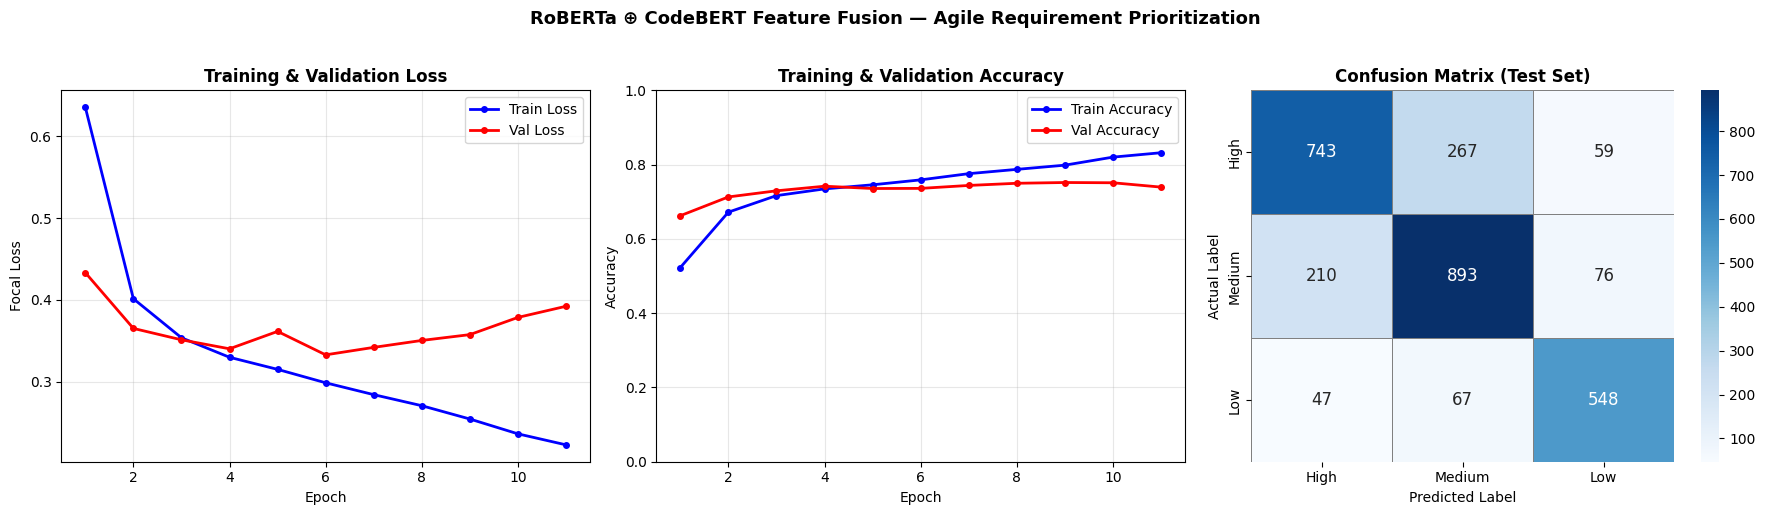

✅ Plots saved → fusion_results_roberta.png


In [12]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot training curves + confusion matrix
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "RoBERTa ⊕ CodeBERT Feature Fusion — Agile Requirement Prioritization",
    fontsize=13, fontweight='bold', y=1.02
)

# ── Loss ─────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], 'b-o', markersize=4,
             linewidth=2, label='Train Loss')
axes[0].plot(x, history['val_loss'],   'r-o', markersize=4,
             linewidth=2, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Accuracy ─────────────────────────────────────────────────
axes[1].plot(x, history['train_acc'], 'b-o', markersize=4,
             linewidth=2, label='Train Accuracy')
axes[1].plot(x, history['val_acc'],   'r-o', markersize=4,
             linewidth=2, label='Val Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Confusion Matrix ─────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels = ['High', 'Medium', 'Low'],
    yticklabels = ['High', 'Medium', 'Low'],
    ax          = axes[2],
    linewidths  = 0.5,
    linecolor   = 'gray',
    annot_kws   = {"size": 12}
)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig("fusion_results_roberta.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved → fusion_results_roberta.png")

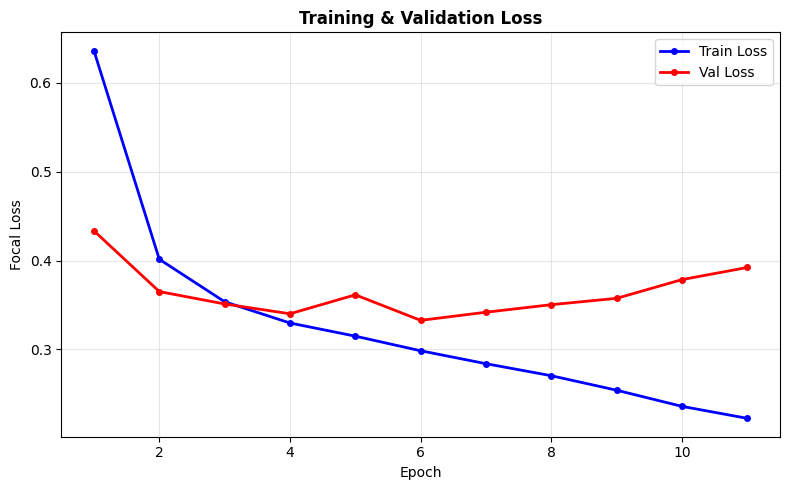

✅ Saved → loss_plot_roberta.png


In [13]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

plt.figure(figsize=(8, 5))

plt.plot(x, history['train_loss'], 'b-o', markersize=4,
         linewidth=2, label='Train Loss')
plt.plot(x, history['val_loss'], 'r-o', markersize=4,
         linewidth=2, label='Val Loss')

plt.title('Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("loss_plot_roberta.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → loss_plot_roberta.png")

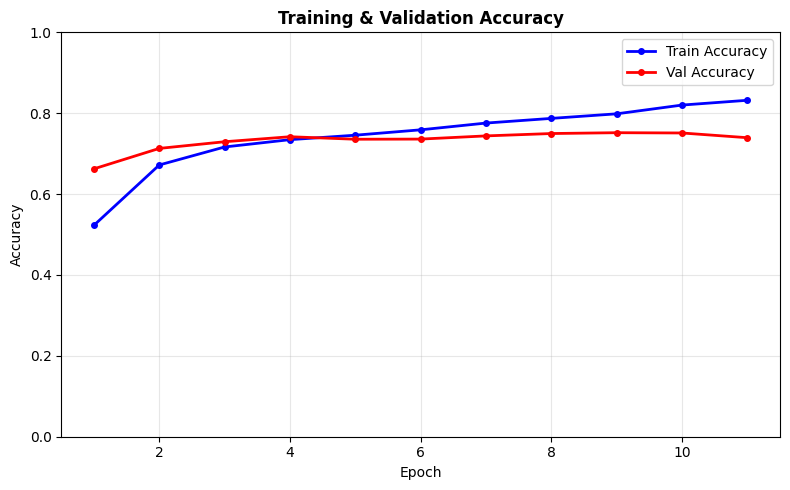

✅ Saved → accuracy_plot_roberta.png


In [14]:
plt.figure(figsize=(8, 5))

plt.plot(x, history['train_acc'], 'b-o', markersize=4,
         linewidth=2, label='Train Accuracy')
plt.plot(x, history['val_acc'], 'r-o', markersize=4,
         linewidth=2, label='Val Accuracy')

plt.title('Training & Validation Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("accuracy_plot_roberta.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → accuracy_plot_roberta.png")

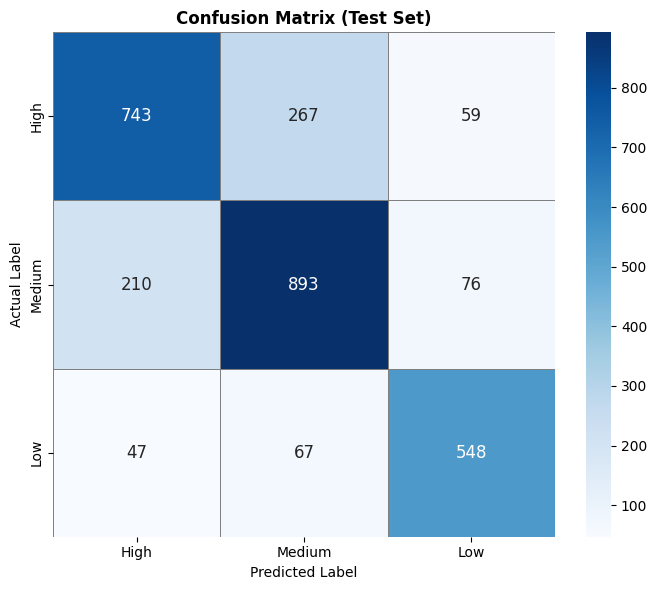

✅ Saved → confusion_matrix_roberta.png


In [15]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Medium', 'Low'],
    yticklabels=['High', 'Medium', 'Low'],
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12}
)

plt.title('Confusion Matrix (Test Set)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.savefig("confusion_matrix_roberta.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → confusion_matrix_roberta.png")

In [16]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Save model + results to Drive — do immediately!
#═══════════════════════════════════════════════════════════════
import shutil
from google.colab import drive, files as colab_files

drive.mount('/content/drive')
os.makedirs("./fusion_model_roberta_v1", exist_ok=True)

# ── Classifier weights ───────────────────────────────────────
torch.save(
    classifier.state_dict(),
    "./fusion_model_roberta_v1/classifier_weights.pt"
)

# ── Finetuned backbone weights ───────────────────────────────
torch.save(
    roberta_model.state_dict(),
    "./fusion_model_roberta_v1/roberta_finetuned.pt"
)
torch.save(
    codebert_model.state_dict(),
    "./fusion_model_roberta_v1/codebert_finetuned.pt"
)

# ── Config ───────────────────────────────────────────────────
config = {
    "roberta_name"  : ROBERTA_NAME,
    "codebert_name" : CODEBERT_NAME,
    "roberta_dim"   : ROBERTA_DIM,
    "codebert_dim"  : CODEBERT_DIM,
    "fused_dim"     : FUSED_DIM,
    "num_classes"   : NUM_CLASSES,
    "max_length"    : MAX_LENGTH,
    "label_map"     : LABEL_MAP,
}
with open("./fusion_model_roberta_v1/config.json", "w") as f:
    json.dump(config, f, indent=2)

# ── Metrics ──────────────────────────────────────────────────
metrics = {
    "accuracy"        : round(acc,            4),
    "precision_macro" : round(precision,      4),
    "recall_macro"    : round(recall,         4),
    "f1_macro"        : round(macro_f1,       4),
    "f1_weighted"     : round(weighted_f1,    4),
    "best_val_loss"   : round(best_val_loss,  4),
    "best_val_macro"  : round(best_val_macro, 4),
}
with open("./fusion_model_roberta_v1/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ── Training history ─────────────────────────────────────────
pd.DataFrame(history).to_csv(
    "./fusion_model_roberta_v1/training_history.csv", index=False
)

# ── Test predictions ─────────────────────────────────────────
pred_df = test_df.copy()
pred_df['predicted_label'] = [INV_LABEL[p] for p in all_preds]
pred_df['true_label']      = [INV_LABEL[l] for l in all_labels]
pred_df['prob_high']       = all_probs[:, 0].round(4)
pred_df['prob_medium']     = all_probs[:, 1].round(4)
pred_df['prob_low']        = all_probs[:, 2].round(4)
pred_df['correct']         = (
    pred_df['predicted_label'] == pred_df['true_label']
)
pred_df.to_csv("./fusion_model_roberta_v1/test_predictions.csv", index=False)

# ── Copy to Google Drive ─────────────────────────────────────
shutil.copytree(
    "./fusion_model_roberta_v1",
    "/content/drive/MyDrive/fusion_model_roberta_v1",
    dirs_exist_ok=True
)
shutil.copy(
    "fusion_results_roberta.png",
    "/content/drive/MyDrive/fusion_results_roberta.png"
)

print("✅ All files saved to Google Drive/fusion_model_roberta_v1/")
print("   classifier_weights.pt")
print("   roberta_finetuned.pt")
print("   codebert_finetuned.pt")
print("   config.json")
print("   metrics.json")
print("   training_history.csv")
print("   test_predictions.csv")
print("   fusion_results_roberta.png")

colab_files.download("./fusion_model_roberta_v1/metrics.json")
colab_files.download("./fusion_model_roberta_v1/test_predictions.csv")
colab_files.download("fusion_results_roberta.png")

print("\n" + "=" * 65)
print("  RESEARCH SUMMARY")
print("=" * 65)
print(f"  Model    : RoBERTa({ROBERTA_DIM}) ⊕ CodeBERT({CODEBERT_DIM})")
print(f"  Task     : Agile Requirement Prioritization")
print(f"  Labels   : High / Medium / Low")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro F1 : {macro_f1:.4f}")
print("=" * 65)

Mounted at /content/drive
✅ All files saved to Google Drive/fusion_model_roberta_v1/
   classifier_weights.pt
   roberta_finetuned.pt
   codebert_finetuned.pt
   config.json
   metrics.json
   training_history.csv
   test_predictions.csv
   fusion_results_roberta.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  RESEARCH SUMMARY
  Model    : RoBERTa(768) ⊕ CodeBERT(768)
  Task     : Agile Requirement Prioritization
  Labels   : High / Medium / Low
  Accuracy : 0.7505
  Macro F1 : 0.7585


In [17]:
#═══════════════════════════════════════════════════════════════
# STEP 13: Test model on unlabeled_dataset.csv
# 98 agile requirements, no labels
#═══════════════════════════════════════════════════════════════
from google.colab import files as colab_files

print("Upload unlabeled_dataset.csv:")
uploaded     = colab_files.upload()
unlabeled_df = pd.read_csv(
    "unlabeled_dataset.csv",
    header = None,
    names  = ['text']
)

unlabeled_df = unlabeled_df.dropna(
    subset=['text']
).reset_index(drop=True)
unlabeled_df['text'] = unlabeled_df['text'].astype(str).str.strip()

print(f"\n✅ Loaded {len(unlabeled_df):,} requirements")

classifier.eval()
roberta_model.eval()
codebert_model.eval()

def predict_single(text):
    rob_enc = roberta_tokenizer(
        text,
        max_length     = MAX_LENGTH,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    code_enc = codebert_tokenizer(
        text,
        max_length     = MAX_LENGTH,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )

    batch = {
        'rob_input_ids'      : rob_enc['input_ids'],
        'rob_attention_mask' : rob_enc['attention_mask'],
        'code_input_ids'     : code_enc['input_ids'],
        'code_attention_mask': code_enc['attention_mask'],
        'label'              : torch.tensor([0])
    }

    rob_emb, code_emb = extract_embeddings(batch, training=False)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = classifier(rob_emb, code_emb)

    probs      = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id    = int(probs.argmax())
    confidence = round(float(probs[pred_id]) * 100, 2)

    return INV_LABEL[pred_id], confidence, {
        'prob_high'  : round(float(probs[0]) * 100, 2),
        'prob_medium': round(float(probs[1]) * 100, 2),
        'prob_low'   : round(float(probs[2]) * 100, 2),
    }

print("\nRunning predictions on all requirements...")
results = []

for idx, row in unlabeled_df.iterrows():
    priority, confidence, probs = predict_single(row['text'])
    results.append({
        'requirement_no' : idx + 1,
        'text'           : row['text'],
        'priority'       : priority,
        'confidence'     : confidence,
        'prob_high'      : probs['prob_high'],
        'prob_medium'    : probs['prob_medium'],
        'prob_low'       : probs['prob_low'],
    })

results_df = pd.DataFrame(results)

priority_order       = {'High': 0, 'Medium': 1, 'Low': 2}
results_df['sort_p'] = results_df['priority'].map(priority_order)
results_df['sort_c'] = -results_df['confidence']
results_df           = results_df.sort_values(
                           ['sort_p', 'sort_c']
                       ).drop(
                           columns=['sort_p', 'sort_c']
                       ).reset_index(drop=True)
results_df.index      += 1
results_df.index.name  = 'rank'

print(f"\n{'Rank':<6} {'Priority':<10} {'Conf%':<8} Requirement")
print("-" * 85)
for idx, row in results_df.iterrows():
    emoji = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}[row['priority']]
    print(f"{idx:<6} {emoji} {row['priority']:<8} "
          f"{row['confidence']:<8}  {row['text'][:60]}...")

high_c   = len(results_df[results_df['priority'] == 'High'])
medium_c = len(results_df[results_df['priority'] == 'Medium'])
low_c    = len(results_df[results_df['priority'] == 'Low'])
avg_conf = results_df['confidence'].mean()

print("\n" + "=" * 85)
print("📊 PREDICTION SUMMARY")
print("=" * 85)
print(f"   Total          : {len(results_df)}")
print(f"   🔴 High        : {high_c}  ({high_c/len(results_df)*100:.1f}%)")
print(f"   🟡 Medium      : {medium_c}  ({medium_c/len(results_df)*100:.1f}%)")
print(f"   🟢 Low         : {low_c}  ({low_c/len(results_df)*100:.1f}%)")
print(f"   Avg confidence : {avg_conf:.2f}%")
print("=" * 85)

results_df.to_csv("unlabeled_predictions_roberta.csv")
results_df.to_csv(
    "/content/drive/MyDrive/unlabeled_predictions_roberta.csv"
)
colab_files.download("unlabeled_predictions_roberta.csv")

print(f"\n✅ Downloaded: unlabeled_predictions_roberta.csv")
print(f"🎯 Done! {len(results_df)} requirements predicted and ranked.")

Upload unlabeled_dataset.csv:


Saving unlabeled_dataset.csv to unlabeled_dataset.csv

✅ Loaded 98 requirements

Running predictions on all requirements...

Rank   Priority   Conf%    Requirement
-------------------------------------------------------------------------------------
1      🔴 High     90.28     As an agency user, I want to be confident that the data comi...
2      🔴 High     82.13     As a Developer, I want D Files generation requests to be man...
3      🔴 High     81.74     As a broker user, I want the historical FABS loader to deriv...
4      🔴 High     80.96     As an owner, I want to be sure that USAspending only send gr...
5      🔴 High     80.71     As a FABS user, I want to have read-only access to DABS, so ...
6      🔴 High     80.13     As an Owner, I want to reset the environment to only take St...
7      🔴 High     78.66     As a user, I want the flexfields in my submission file to ap...
8      🔴 High     77.78     As a FABS user, I do not want  DABS banner messages and vice...
9      🔴 High 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded: unlabeled_predictions_roberta.csv
🎯 Done! 98 requirements predicted and ranked.
